# Import dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from prophet import Prophet

import os




In [2]:
url = "https://docs.google.com/spreadsheets/d/1TijL04FxIzipbjtJZkgdxvx1Y1AcvvfoV3LZGVtzPho/export?format=csv"

df = pd.read_csv(url)
print(df.head())

        Month                Category Week Hub Shipped Qty
0  2022-01-01  A. Bahan & Bumbu Masak   W1   A      150.00
1  2022-01-01  A. Bahan & Bumbu Masak   W2   A      200.00
2  2022-01-01  A. Bahan & Bumbu Masak   W3   A      250.00
3  2022-01-01  A. Bahan & Bumbu Masak   W4   A      400.00
4  2022-01-01          B. Daging Beku   W1   A      150.00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        1400 non-null   object
 1   Category     1400 non-null   object
 2   Week         1400 non-null   object
 3   Hub          1400 non-null   object
 4   Shipped Qty  1400 non-null   object
dtypes: object(5)
memory usage: 54.8+ KB


# Data Cleaning

Memperbaiki type data ( Month - datetime & Quantity Qty - Float )

In [4]:
# datetime
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
# Text (Category & Hub)
df['Category'] = (
    df['Category']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()          # jadi Title Case
)

df['Hub'] = (
    df['Hub']
    .astype(str)
    .str.strip()
    .str.upper()          # contoh: A, B, C
)

# missing value
num_cols = ['Shipped Qty']

for col in num_cols:
  df[col] = pd.to_numeric(df[col], errors='coerce')
  df[col] = df[col].fillna(df[col].median())

# Text "Unknown" / "Null"
text_cols = ['Category', 'Hub', 'Week']
df[text_cols] = df[text_cols].fillna("Unknown")

# Nilai Negatif / Tidak logis
df['Shipped Qty'] = df['Shipped Qty'].clip(lower=0)

# Normalisasi Week Format W1 -> W01
df['Week'] = (
    df['Week']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)  # ambil angka
    .astype(int)
    .astype(str)
    .str.zfill(2)
)
df['Week'] = 'W' + df['Week']

#=============
print(df.head())
print(df.info())

df.to_csv("Data_Cleaned.csv", index=False)

       Month                Category Week Hub  Shipped Qty
0 2022-01-01  A. Bahan & Bumbu Masak  W01   A        150.0
1 2022-01-01  A. Bahan & Bumbu Masak  W02   A        200.0
2 2022-01-01  A. Bahan & Bumbu Masak  W03   A        250.0
3 2022-01-01  A. Bahan & Bumbu Masak  W04   A        400.0
4 2022-01-01          B. Daging Beku  W01   A        150.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        1400 non-null   datetime64[ns]
 1   Category     1400 non-null   object        
 2   Week         1400 non-null   object        
 3   Hub          1400 non-null   object        
 4   Shipped Qty  1400 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 54.8+ KB
None


# Exploratory Data Analysis (EDA)

## BASIC OVERVIEW

Data Bersih ( No Missing / Duplicate)


In [5]:
dfc = pd.read_csv("Data_Cleaned.csv")

date_col = 'Month' if 'Month' in dfc.columns else 'date'
demand_col = 'Shipped Qty'
category_col = 'Category'

# Format Tanggal
dfc[date_col] = pd.to_datetime(dfc[date_col])

print(df.info())
print("\nHead:\n", dfc.head())
print("\nMissing values:\n", dfc.isna().sum())
duplicates = dfc.duplicated().sum()
print(f"\nJumlah duplikat:", duplicates)
print("\nDescribe:\n", dfc.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        1400 non-null   datetime64[ns]
 1   Category     1400 non-null   object        
 2   Week         1400 non-null   object        
 3   Hub          1400 non-null   object        
 4   Shipped Qty  1400 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 54.8+ KB
None

Head:
        Month                Category Week Hub  Shipped Qty
0 2022-01-01  A. Bahan & Bumbu Masak  W01   A        150.0
1 2022-01-01  A. Bahan & Bumbu Masak  W02   A        200.0
2 2022-01-01  A. Bahan & Bumbu Masak  W03   A        250.0
3 2022-01-01  A. Bahan & Bumbu Masak  W04   A        400.0
4 2022-01-01          B. Daging Beku  W01   A        150.0

Missing values:
 Month          0
Category       0
Week           0
Hub            0
Shipped Qty    0
dtype: in

## Info Weekly


=== TOTAL DEMAND PER WEEK ===
        Month Week  Shipped Qty
0  2022-01-01  W01       8691.0
1  2022-01-01  W02      11580.0
2  2022-01-01  W03      14481.0
3  2022-01-01  W04      18327.0
4  2022-02-01  W01      22013.0
5  2022-02-01  W02      23713.5
6  2022-02-01  W03      25850.0
7  2022-02-01  W04      25606.5
8  2022-03-01  W01      24011.5
9  2022-03-01  W02      25488.5
10 2022-03-01  W03      27101.0
11 2022-03-01  W04      25318.5
12 2022-04-01  W01      24716.5
13 2022-04-01  W02      27006.0
14 2022-04-01  W03      25683.5
15 2022-04-01  W04      23524.5
16 2022-05-01  W01      26139.5
17 2022-05-01  W02      25496.5
18 2022-05-01  W03      27456.5
19 2022-05-01  W04      25033.5
20 2022-06-01  W01      25457.0
21 2022-06-01  W02      25476.5
22 2022-06-01  W03      28157.0
23 2022-06-01  W04      23798.0
24 2022-07-01  W01      24619.5
25 2022-07-01  W02      26285.5
26 2022-07-01  W03      27261.5
27 2022-07-01  W04      23334.0

=== TOTAL DEMAND PER MONTH ===
       Mo

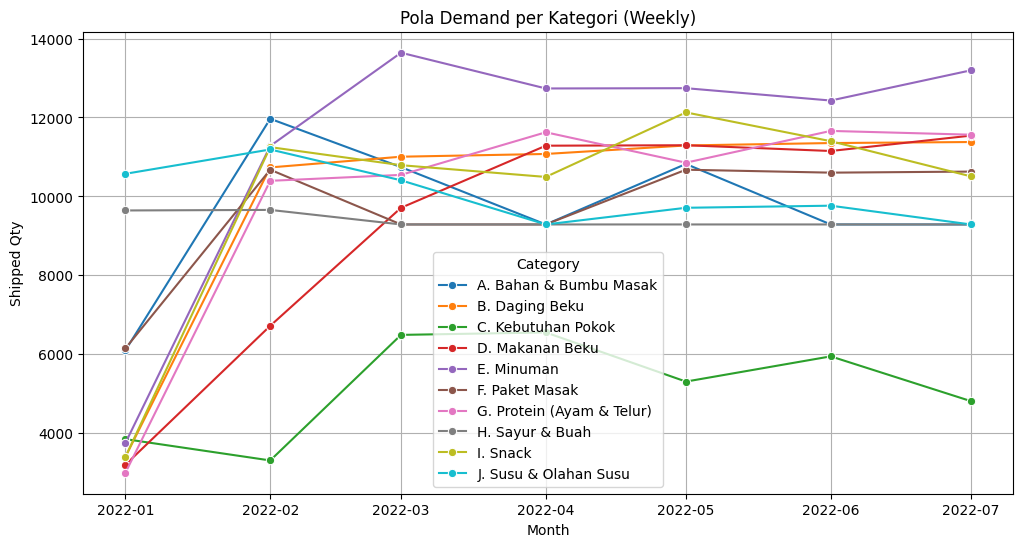


=== STATISTIK DEMAND GLOBAL ===
Mean: 472.5907142857143
Min: 60.0
Max: 998.0
Std Dev: 192.87868442215645
Variasi (Max - Min): 938.0


In [6]:
weekly = dfc.groupby(['Month', 'Week'])['Shipped Qty'].sum().reset_index()
monthly = dfc.groupby('Month')['Shipped Qty'].sum().reset_index()

print("\n=== TOTAL DEMAND PER WEEK ===")
print(weekly)

print("\n=== TOTAL DEMAND PER MONTH ===")
print(monthly)

category_summary = dfc.groupby('Category')['Shipped Qty'].agg(['sum', 'mean', 'min', 'max', 'std'])
print("\n=== DEMAND PER CATEGORY ===")
print(category_summary)

weekly_cat = df.groupby(['Month', 'Category'])['Shipped Qty'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=weekly_cat, x='Month', y='Shipped Qty', hue='Category', marker='o')
plt.title("Pola Demand per Kategori (Weekly)")
plt.xlabel("Month")
plt.ylabel("Shipped Qty")
plt.legend(title="Category")
plt.grid(True)
plt.show()


print("\n=== STATISTIK DEMAND GLOBAL ===")
print("Mean:", dfc['Shipped Qty'].mean())
print("Min:", dfc['Shipped Qty'].min())
print("Max:", dfc['Shipped Qty'].max())
print("Std Dev:", dfc['Shipped Qty'].std())
print("Variasi (Max - Min):", dfc['Shipped Qty'].max() - dfc['Shipped Qty'].min())

## Trend naik turun (persentase)


=== TREND MONTHLY (% CHANGE) ===
       Month  Shipped Qty   Change %
0 2022-01-01      53079.0        NaN
1 2022-02-01      97183.0  83.091241
2 2022-03-01     101919.5   4.873795
3 2022-04-01     100930.5  -0.970374
4 2022-05-01     104126.0   3.166040
5 2022-06-01     102888.5  -1.188464
6 2022-07-01     101500.5  -1.349033

=== TREND WEEKLY (% CHANGE) ===
        Month Week  Shipped Qty   Change %
0  2022-01-01  W01       8691.0        NaN
1  2022-01-01  W02      11580.0  33.241284
2  2022-01-01  W03      14481.0  25.051813
3  2022-01-01  W04      18327.0  26.558939
4  2022-02-01  W01      22013.0  20.112402
5  2022-02-01  W02      23713.5   7.724981
6  2022-02-01  W03      25850.0   9.009636
7  2022-02-01  W04      25606.5  -0.941973
8  2022-03-01  W01      24011.5  -6.228887
9  2022-03-01  W02      25488.5   6.151219
10 2022-03-01  W03      27101.0   6.326382
11 2022-03-01  W04      25318.5  -6.577248
12 2022-04-01  W01      24716.5  -2.377708
13 2022-04-01  W02      27006.0   9

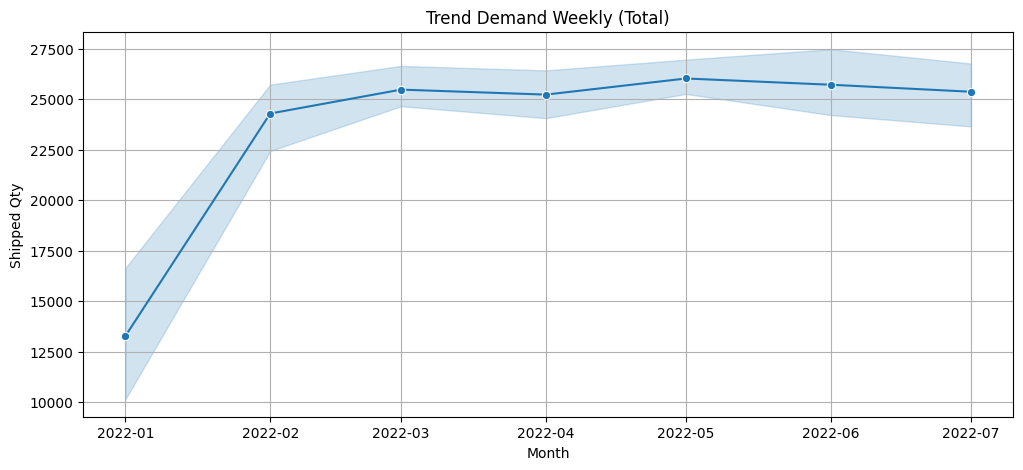


=== RATA-RATA DEMAND PER BULAN (SEASONALITY) ===
Month
1    265.3950
2    485.9150
3    509.5975
4    504.6525
5    520.6300
6    514.4425
7    507.5025
Name: Shipped Qty, dtype: float64

=== RATA-RATA DEMAND PER WEEK CODE (SEASONALITY) ===
Week
W01    444.708571
W02    471.561429
W03    502.830000
W04    471.262857
Name: Shipped Qty, dtype: float64


In [7]:
monthly['Change %'] = monthly['Shipped Qty'].pct_change() * 100
weekly['Change %'] = weekly['Shipped Qty'].pct_change() * 100

print("\n=== TREND MONTHLY (% CHANGE) ===")
print(monthly[['Month', 'Shipped Qty', 'Change %']])

print("\n=== TREND WEEKLY (% CHANGE) ===")
print(weekly[['Month', 'Week', 'Shipped Qty', 'Change %']])

weekly = df.groupby(['Month', 'Week'])['Shipped Qty'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=weekly, x='Month', y='Shipped Qty', marker='o')
plt.title("Trend Demand Weekly (Total)")
plt.xlabel("Month")
plt.ylabel("Shipped Qty")
plt.grid(True)
plt.show()


season_month = df.groupby(df['Month'].dt.month)['Shipped Qty'].mean()
season_week = df.groupby('Week')['Shipped Qty'].mean()

print("\n=== RATA-RATA DEMAND PER BULAN (SEASONALITY) ===")
print(season_month)

print("\n=== RATA-RATA DEMAND PER WEEK CODE (SEASONALITY) ===")
print(season_week)


**Outlier Solving**


=== OUTLIERS TERDETEKSI (Z-Score > 3) ===
Empty DataFrame
Columns: [Month, Category, Week, Hub, Shipped Qty, Zscore]
Index: []

Jumlah outlier: 0


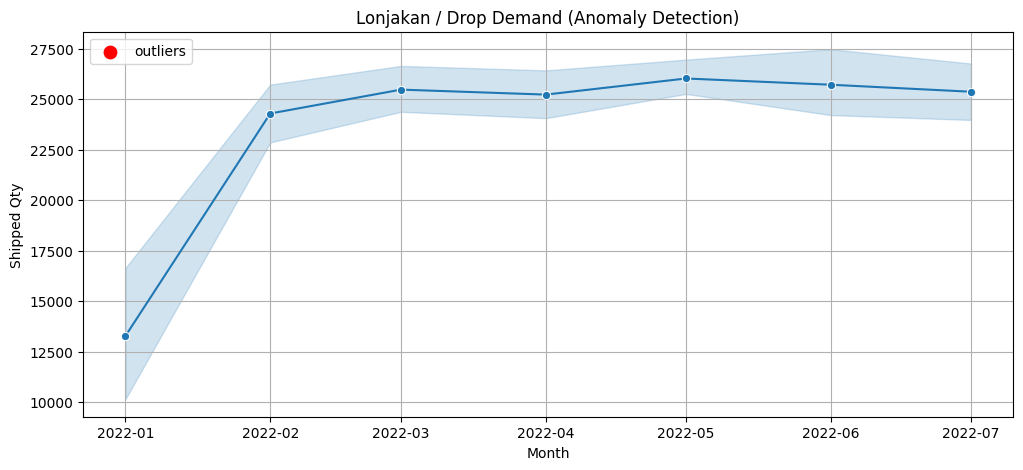

In [8]:
dfc['Zscore'] = (dfc['Shipped Qty'] - dfc['Shipped Qty'].mean()) / dfc['Shipped Qty'].std()
outliers = dfc[dfc['Zscore'].abs() > 3]

print("\n=== OUTLIERS TERDETEKSI (Z-Score > 3) ===")
print(outliers)

print("\nJumlah outlier:", len(outliers))




plt.figure(figsize=(12,5))
sns.lineplot(data=weekly, x='Month', y='Shipped Qty', marker='o')

plt.scatter(outliers['Month'], outliers['Shipped Qty'], color='red', s=80, label='outliers')

plt.title("Lonjakan / Drop Demand (Anomaly Detection)")
plt.xlabel("Month")
plt.ylabel("Shipped Qty")
plt.legend()
plt.grid(True)
plt.show()


**AGGREGATION**

In [9]:
monthly_forecast_base = dfc.groupby('Month')['Shipped Qty'].sum().reset_index()
monthly_forecast_base.to_csv("monthly_aggregated.csv", index=False)

print("\nFILE monthly_aggregated.csv siap digunakan untuk forecasting.")

fb = pd.read_csv("monthly_aggregated.csv")
print(fb)


FILE monthly_aggregated.csv siap digunakan untuk forecasting.
        Month  Shipped Qty
0  2022-01-01      53079.0
1  2022-02-01      97183.0
2  2022-03-01     101919.5
3  2022-04-01     100930.5
4  2022-05-01     104126.0
5  2022-06-01     102888.5
6  2022-07-01     101500.5


In [10]:
pivot_cat = dfc.pivot_table(
    index='Month',
    columns='Category',
    values='Shipped Qty',
    aggfunc='sum'
).fillna(0)

pivot_cat.to_csv("monthly_by_category.csv")

print("\nFILE monthly_by_category.csv dibuat.")

print(pd.read_csv("monthly_by_category.csv"))


FILE monthly_by_category.csv dibuat.
        Month  A. Bahan & Bumbu Masak  B. Daging Beku  C. Kebutuhan Pokok  \
0  2022-01-01                  6102.0          3402.0              3851.0   
1  2022-02-01                 11967.0         10735.0              3311.0   
2  2022-03-01                 10742.0         11006.5              6492.0   
3  2022-04-01                  9290.0         11076.0              6554.0   
4  2022-05-01                 10822.5         11291.5              5309.0   
5  2022-06-01                  9290.0         11352.5              5948.0   
6  2022-07-01                  9290.0         11378.5              4814.0   

   D. Makanan Beku  E. Minuman  F. Paket Masak  G. Protein (Ayam & Telur)  \
0           3202.0      3753.0          6151.0                     3000.0   
1           6722.0     11278.5         10677.0                    10395.5   
2           9712.0     13641.0          9290.0                    10546.0   
3          11285.5     12735.5       

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
dfc['Scaled Demand'] = scaler.fit_transform(dfc[['Shipped Qty']])

print("\n=== SAMPLE DATASET DENGAN SCALING ===")
print(dfc.head())


=== SAMPLE DATASET DENGAN SCALING ===
       Month                Category Week Hub  Shipped Qty    Zscore  \
0 2022-01-01  A. Bahan & Bumbu Masak  W01   A        150.0 -1.672506   
1 2022-01-01  A. Bahan & Bumbu Masak  W02   A        200.0 -1.413275   
2 2022-01-01  A. Bahan & Bumbu Masak  W03   A        250.0 -1.154045   
3 2022-01-01  A. Bahan & Bumbu Masak  W04   A        400.0 -0.376354   
4 2022-01-01          B. Daging Beku  W01   A        150.0 -1.672506   

   Scaled Demand  
0       0.095949  
1       0.149254  
2       0.202559  
3       0.362473  
4       0.095949  


# Forecasting

In [12]:
dfc['Month'] = pd.to_datetime(dfc['Month'])
dfc['Shipped Qty'] = pd.to_numeric(dfc['Shipped Qty'], errors='coerce').fillna(0)

monthly = (
    df.groupby(df['Month'].dt.to_period('M'))['Shipped Qty']
    .sum()
    .reset_index()
)

monthly['Month'] = monthly['Month'].dt.to_timestamp()

monthly = monthly.set_index('Month')
print("Monthly Data :")
print(monthly)

Monthly Data :
            Shipped Qty
Month                  
2022-01-01      53079.0
2022-02-01      97183.0
2022-03-01     101919.5
2022-04-01     100930.5
2022-05-01     104126.0
2022-06-01     102888.5
2022-07-01     101500.5


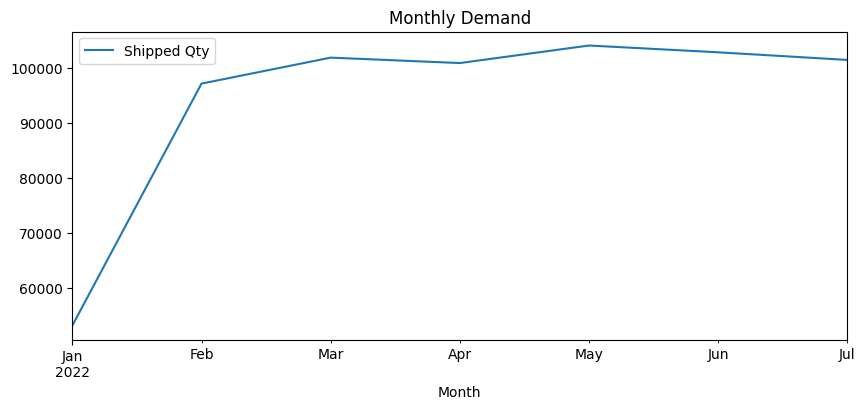

In [13]:
# PLOT DEMAND MONTHLY
monthly.plot(figsize=(10,4), title="Monthly Demand")
plt.show()

In [14]:
y = monthly['Shipped Qty']

# Train data sampai Juli 2022
train = y.loc[y.index < "2022-08-01"]

## MOVING AVERAGE (Baseline)

In [15]:
ma_forecast = train.rolling(window=3).mean().iloc[-1]
print("\nMoving Average Forecast (3-month):", ma_forecast)


Moving Average Forecast (3-month): 102838.33333333333


## EXPONENTIAL SMOOTHING (HOLT-WINTERS)

In [16]:
hw_model = ExponentialSmoothing(train, trend='add', seasonal=None).fit()
hw_forecast = hw_model.forecast(1)[0]
print("\nHolt-Winters Forecast:", hw_forecast)


Holt-Winters Forecast: 99724.06021199955


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-3560476780.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hw_forecast = hw_model.forecast(1)[0]


## SARIMA

In [17]:
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(0,0,0,12)).fit(disp=False)
sarima_forecast = sarima_model.forecast(1)[0]
print("\nSARIMA Forecast:", sarima_forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



SARIMA Forecast: 100649.80702120492


/tmp/ipython-input-3040509219.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sarima_forecast = sarima_model.forecast(1)[0]


## PROPHET

In [18]:
df_prophet = train.reset_index()
df_prophet.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=1, freq='M')
prophet_forecast = prophet_model.predict(future).iloc[-1]['yhat']
print("\nProphet Forecast:", prophet_forecast)

INFO:prophet:n_changepoints greater than number of observations. Using 4.



Prophet Forecast: 117179.15528924872


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [19]:
results = pd.DataFrame({
    'Model': ['Moving Average', 'Holt-Winters', 'SARIMA', 'Prophet'],
    'Forecast_Aug_2022': [ma_forecast, hw_forecast, sarima_forecast, prophet_forecast]
})

print("\n=== BENCHMARK FORECAST RESULTS ===")
print(results)


=== BENCHMARK FORECAST RESULTS ===
            Model  Forecast_Aug_2022
0  Moving Average      102838.333333
1    Holt-Winters       99724.060212
2          SARIMA      100649.807021
3         Prophet      117179.155289


In [20]:
best_model = results.set_index('Model').mean(axis=1).idxmin()
print("\nModel terbaik secara stabilitas dataset pendek:", best_model)


Model terbaik secara stabilitas dataset pendek: Holt-Winters


# Simulasi

In [21]:
import pandas as pd
import numpy as np

In [22]:
dfc['Month'] = pd.to_datetime(dfc['Month'])
# Grouping biar jadi total per Bulan per Hub per Kategori
df_monthly = dfc.groupby(['Month', 'Hub', 'Category'])['Shipped Qty'].sum().reset_index()


In [23]:
# Fungsi Forecast Sederhana
def simple_forecast(series, method='naive', window=2):
    if len(series) == 0: return 0

    if method == 'naive':
        return series.iloc[-1] # Ambil bulan terakhir

    elif method == 'moving_average':
        if len(series) < window: return series.mean() # Kalau data dikit, ambil rata-rata semua
        return series.iloc[-window:].mean() # Rata-rata X bulan terakhir

    elif method == 'exp_smoothing':
        # Simple Alpha 0.5 (Jalan tengah)
        return series.ewm(alpha=0.5, adjust=False).mean().iloc[-1]

    return 0

In [24]:
# Training nebak Juli pake data Jan-Jun
train_data = df_monthly[df_monthly['Month'] < '2022-07-01']
test_data_july = df_monthly[df_monthly['Month'] == '2022-07-01']

errors = {'naive': [], 'moving_average': [], 'exp_smoothing': []}

hub_acuan = 'A'
categories = df_monthly['Category'].unique()

for cat in categories:
    series = train_data[(train_data['Hub'] == hub_acuan) & (train_data['Category'] == cat)]['Shipped Qty']
    actual_july = test_data_july[(test_data_july['Hub'] == hub_acuan) & (test_data_july['Category'] == cat)]['Shipped Qty'].sum()

    if len(series) > 0:
        # Hitung Error (Selisih Absolut)
        pred_naive = simple_forecast(series, 'naive')
        errors['naive'].append(abs(pred_naive - actual_july))

        pred_ma = simple_forecast(series, 'moving_average')
        errors['moving_average'].append(abs(pred_ma - actual_july))

        pred_es = simple_forecast(series, 'exp_smoothing')
        errors['exp_smoothing'].append(abs(pred_es - actual_july))

In [25]:
avg_errors = {k: np.mean(v) for k, v in errors.items()}
best_method = min(avg_errors, key=avg_errors.get)

print(f"--- HASIL ANALISA ---")
print(f"Metode dengan Error Terendah (MAE): {best_method.upper()}")
print(f"Rata-rata Meleset (Error): {avg_errors[best_method]:.2f} unit\n")

# 6. Forecast Agustus 2022 untuk HUB BARU (Hub E)
print(f"--- FORECAST AGUSTUS 2022 (HUB E) ---")
target_hub = 'E' # Asumsi Hub E adalah New Hub
forecast_results = []

for cat in categories:
    # Ambil semua data sampai Juli
    series_full = df_monthly[(df_monthly['Hub'] == target_hub) & (df_monthly['Category'] == cat)]['Shipped Qty']

    # Prediksi Agustus pakai metode terbaik
    prediction = simple_forecast(series_full, best_method)

    forecast_results.append({'Category': cat, 'Aug_Forecast': prediction})
    print(f"Kategori {cat}: {prediction:.2f}")

--- HASIL ANALISA ---
Metode dengan Error Terendah (MAE): NAIVE
Rata-rata Meleset (Error): 66.80 unit

--- FORECAST AGUSTUS 2022 (HUB E) ---
Kategori A. Bahan & Bumbu Masak: 1858.00
Kategori B. Daging Beku: 2398.00
Kategori C. Kebutuhan Pokok: 625.00
Kategori D. Makanan Beku: 2816.50
Kategori E. Minuman: 2749.50
Kategori F. Paket Masak: 2379.50
Kategori G. Protein (Ayam & Telur): 2211.50
Kategori H. Sayur & Buah: 1858.00
Kategori I. Snack: 2287.50
Kategori J. Susu & Olahan Susu: 1858.00


In [26]:
final_df = pd.DataFrame(forecast_results)

In [27]:
# Timeline Mingguan (Continous)
dfc['Month_Week'] = dfc['Month'].dt.strftime('%b') + '-' + dfc['Week']
# Sort - urutin data
dfc['Week_Num'] = dfc['Week'].str.extract('(\d+)').astype(int)

df_sorted = df.sort_values(by=['Month', 'Week_Num'])

# Label & Agregasi
df_sorted['Month_Week'] = df_sorted['Month'].dt.strftime('%b') + '-' + df_sorted['Week']

# Total per minggu
weekly_trendy = df_sorted.groupby(['Month', 'Week', 'Month_Week'], sort=False)['Shipped Qty'].sum().reset_index()

# Visualisasi
plt.figure(figsize=(18, 6))
sns.lineplot(data=weekly_trendy, x='Month_Week', y='Shipped Qty', marker='o', color='teal', linewidth=2)
plt.title('Tren Permintaan Mingguan (Januari - Juli 2022)')
plt.xlabel('Bulan - Minggu')
plt.ylabel('Total Barang Terkirim')
plt.xticks(rotation=45) # Corrected typo from plt.AbstractContextManager=45
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3355552780.py:4: SyntaxWarning: invalid escape sequence '\d'
  dfc['Week_Num'] = dfc['Week'].str.extract('(\d+)').astype(int)


KeyError: 'Week_Num'